In [198]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
mean_absolute_error,
mean_squared_error,
root_mean_squared_error,
r2_score
)
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import (
accuracy_score,
confusion_matrix,
precision_score,
recall_score,
classification_report
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import TargetEncoder

In [136]:
df = pd.read_csv(r"C:\Users\lenovo\.cache\kagglehub\datasets\parthrider04\synthetic-fare-dataset\versions\1\Synthetic_Fare_Dataset.csv")

In [137]:
df.columns

Index(['source_dataset', 'date', 'hour', 'vehicle_type', 'pickup_location',
       'drop_location', 'distance_km', 'fare_amount', 'payment_method',
       'status', 'driver_rating', 'customer_rating', 'year', 'month', 'day',
       'weekday', 'state', 'season', 'weather', 'phase_of_day',
       'is_phase_imputed'],
      dtype='object')

In [138]:
df=df.drop(columns=["date","pickup_location","drop_location","customer_rating","is_phase_imputed"])

In [139]:
df = df[df['source_dataset'] != 'delhi_notification_2023'].copy()
df = df[df['source_dataset'] != "aru_dto_2019"].copy()

In [140]:
df

,source_dataset,hour,vehicle_type,distance_km,fare_amount,payment_method,status,driver_rating,year,month,day,weekday,state,season,weather,phase_of_day
0,bengaluru_ola,6.0,auto,28.50,868.06,wallet,success,4.4,2024.0,1.0,28.0,Sunday,Karnataka,winter,not_applicable,morning
1,bengaluru_ola,21.0,prime sedan,25.18,348.04,card,success,4.5,2024.0,1.0,17.0,Wednesday,Karnataka,winter,not_applicable,night
2,bengaluru_ola,0.0,ebike,17.67,56.33,upi,success,3.6,2024.0,1.0,30.0,Tuesday,Karnataka,winter,not_applicable,midnight
3,bengaluru_ola,8.0,prime suv,24.94,1971.38,upi,success,3.2,2024.0,1.0,22.0,Monday,Karnataka,winter,not_applicable,morning
4,bengaluru_ola,7.0,prime sedan,13.15,1130.15,card,success,3.1,2024.0,1.0,12.0,Friday,Karnataka,winter,not_applicable,morning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392237,indore_ola,NaN,prime sedan,17.73,908.00,cash,canceled by driver,4.2,2025.0,1.0,2.0,Thursday,Madhya Pradesh,winter,not_applicable,evening
392238,indore_ola,NaN,bike,18.34,676.00,cash,success,3.9,2025.0,1.0,30.0,Thursday,Madhya Pradesh,winter,not_applicable,evening
392239,indore_ola,NaN,prime plus,9.28,780.00,cash,canceled by driver,4.2,2025.0,1.0,8.0,Wednesday,Madhya Pradesh,winter,not_applicable,night
392240,indore_ola,NaN,mini,3.32,1852.00,cash,canceled by driver,4.2,2025.0,1.0,12.0,Sunday,Madhya Pradesh,winter,not_applicable,night


In [141]:
allowed_vehicle_types = [
    # Bikes
    'bike',
    'ebike',
    'bike lite',

    # Cars / Cabs
    'prime sedan',
    'prime plus',
    'prime suv',
    'mini',
    'go mini',
    'go sedan',
    'premier sedan',
    'cab economy',
    'uber xl',
    'taxi_non_ac',
    'taxi_ac',
    'tata_sumo',

    # Autos
    'auto',
    'auto_rickshaw',
    'auto_iris'
]

df = df[df['vehicle_type'].isin(allowed_vehicle_types)].copy()
df

,source_dataset,hour,vehicle_type,distance_km,fare_amount,payment_method,status,driver_rating,year,month,day,weekday,state,season,weather,phase_of_day
0,bengaluru_ola,6.0,auto,28.50,868.06,wallet,success,4.4,2024.0,1.0,28.0,Sunday,Karnataka,winter,not_applicable,morning
1,bengaluru_ola,21.0,prime sedan,25.18,348.04,card,success,4.5,2024.0,1.0,17.0,Wednesday,Karnataka,winter,not_applicable,night
2,bengaluru_ola,0.0,ebike,17.67,56.33,upi,success,3.6,2024.0,1.0,30.0,Tuesday,Karnataka,winter,not_applicable,midnight
3,bengaluru_ola,8.0,prime suv,24.94,1971.38,upi,success,3.2,2024.0,1.0,22.0,Monday,Karnataka,winter,not_applicable,morning
4,bengaluru_ola,7.0,prime sedan,13.15,1130.15,card,success,3.1,2024.0,1.0,12.0,Friday,Karnataka,winter,not_applicable,morning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392237,indore_ola,NaN,prime sedan,17.73,908.00,cash,canceled by driver,4.2,2025.0,1.0,2.0,Thursday,Madhya Pradesh,winter,not_applicable,evening
392238,indore_ola,NaN,bike,18.34,676.00,cash,success,3.9,2025.0,1.0,30.0,Thursday,Madhya Pradesh,winter,not_applicable,evening
392239,indore_ola,NaN,prime plus,9.28,780.00,cash,canceled by driver,4.2,2025.0,1.0,8.0,Wednesday,Madhya Pradesh,winter,not_applicable,night
392240,indore_ola,NaN,mini,3.32,1852.00,cash,canceled by driver,4.2,2025.0,1.0,12.0,Sunday,Madhya Pradesh,winter,not_applicable,night


In [142]:
vehicle_mapping = {
    # Auto
    'auto': 'auto',
    'auto_rickshaw': 'auto',
    'auto_iris': 'auto',

    # Sedan AC
    'prime sedan': 'cab_ac',
    'prime plus': 'cab_ac',
    'go sedan': 'cab_ac',
    'uber xl': 'cab_ac',
    'taxi_ac': 'cab_ac',

    # SUV
    'prime suv': 'cab_suv',
    'tata_sumo': 'cab_suv',

    # Premier Sedan
    'premier sedan': 'premier_sedan',

    # Cab
    'mini': 'cab',
    'go mini': 'cab',
    'cab economy': 'cab',
    'taxi_non_ac': 'cab',

    # Bike
    'bike': 'bike',
    'ebike': 'bike',
    'bike lite': 'bike'
}

df['vehicle_type'] = df['vehicle_type'].replace(vehicle_mapping)
df

,source_dataset,hour,vehicle_type,distance_km,fare_amount,payment_method,status,driver_rating,year,month,day,weekday,state,season,weather,phase_of_day
0,bengaluru_ola,6.0,auto,28.50,868.06,wallet,success,4.4,2024.0,1.0,28.0,Sunday,Karnataka,winter,not_applicable,morning
1,bengaluru_ola,21.0,cab_ac,25.18,348.04,card,success,4.5,2024.0,1.0,17.0,Wednesday,Karnataka,winter,not_applicable,night
2,bengaluru_ola,0.0,bike,17.67,56.33,upi,success,3.6,2024.0,1.0,30.0,Tuesday,Karnataka,winter,not_applicable,midnight
3,bengaluru_ola,8.0,cab_suv,24.94,1971.38,upi,success,3.2,2024.0,1.0,22.0,Monday,Karnataka,winter,not_applicable,morning
4,bengaluru_ola,7.0,cab_ac,13.15,1130.15,card,success,3.1,2024.0,1.0,12.0,Friday,Karnataka,winter,not_applicable,morning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392237,indore_ola,NaN,cab_ac,17.73,908.00,cash,canceled by driver,4.2,2025.0,1.0,2.0,Thursday,Madhya Pradesh,winter,not_applicable,evening
392238,indore_ola,NaN,bike,18.34,676.00,cash,success,3.9,2025.0,1.0,30.0,Thursday,Madhya Pradesh,winter,not_applicable,evening
392239,indore_ola,NaN,cab_ac,9.28,780.00,cash,canceled by driver,4.2,2025.0,1.0,8.0,Wednesday,Madhya Pradesh,winter,not_applicable,night
392240,indore_ola,NaN,cab,3.32,1852.00,cash,canceled by driver,4.2,2025.0,1.0,12.0,Sunday,Madhya Pradesh,winter,not_applicable,night


In [143]:
df.isna().sum()

source_dataset         0
hour              138217
vehicle_type           0
distance_km            0
fare_amount            0
payment_method         0
status                 0
driver_rating          0
year                   0
month                  0
day                    0
weekday                0
state                  0
season                 0
weather                0
phase_of_day           0
dtype: int64

In [144]:
df["vehicle_type"].value_counts()

vehicle_type
bike             109653
cab_ac            90896
auto              72174
cab               64321
cab_suv           33772
premier_sedan     13238
Name: count, dtype: int64

In [145]:
PAYMENT_MAP = {
    "cash": "cash",
    "card": "card", "credit card": "card", "debit card": "card",
    "upi": "upi", "gpay": "upi", "qr scan": "upi",
    "wallet": "wallet", "uber wallet": "wallet", "paytm": "wallet", "amazon pay": "wallet",
}

In [146]:
df["payment_method"] = df["payment_method"].replace(PAYMENT_MAP)

In [147]:
df

,source_dataset,hour,vehicle_type,distance_km,fare_amount,payment_method,status,driver_rating,year,month,day,weekday,state,season,weather,phase_of_day
0,bengaluru_ola,6.0,auto,28.50,868.06,wallet,success,4.4,2024.0,1.0,28.0,Sunday,Karnataka,winter,not_applicable,morning
1,bengaluru_ola,21.0,cab_ac,25.18,348.04,card,success,4.5,2024.0,1.0,17.0,Wednesday,Karnataka,winter,not_applicable,night
2,bengaluru_ola,0.0,bike,17.67,56.33,upi,success,3.6,2024.0,1.0,30.0,Tuesday,Karnataka,winter,not_applicable,midnight
3,bengaluru_ola,8.0,cab_suv,24.94,1971.38,upi,success,3.2,2024.0,1.0,22.0,Monday,Karnataka,winter,not_applicable,morning
4,bengaluru_ola,7.0,cab_ac,13.15,1130.15,card,success,3.1,2024.0,1.0,12.0,Friday,Karnataka,winter,not_applicable,morning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392237,indore_ola,NaN,cab_ac,17.73,908.00,cash,canceled by driver,4.2,2025.0,1.0,2.0,Thursday,Madhya Pradesh,winter,not_applicable,evening
392238,indore_ola,NaN,bike,18.34,676.00,cash,success,3.9,2025.0,1.0,30.0,Thursday,Madhya Pradesh,winter,not_applicable,evening
392239,indore_ola,NaN,cab_ac,9.28,780.00,cash,canceled by driver,4.2,2025.0,1.0,8.0,Wednesday,Madhya Pradesh,winter,not_applicable,night
392240,indore_ola,NaN,cab,3.32,1852.00,cash,canceled by driver,4.2,2025.0,1.0,12.0,Sunday,Madhya Pradesh,winter,not_applicable,night


In [148]:
df["payment_method"].value_counts()

payment_method
cash      209807
upi       102575
wallet     40549
card       31123
Name: count, dtype: int64

In [149]:
df["phase_of_day"].value_counts()

phase_of_day
morning           102360
night              85999
afternoon          67402
evening            64229
midnight           41876
before_sunrise     22188
Name: count, dtype: int64

In [150]:
df=df.drop(columns=["year","month","day","source_dataset","hour"])

In [151]:
df

,vehicle_type,distance_km,fare_amount,payment_method,status,driver_rating,weekday,state,season,weather,phase_of_day
0,auto,28.50,868.06,wallet,success,4.4,Sunday,Karnataka,winter,not_applicable,morning
1,cab_ac,25.18,348.04,card,success,4.5,Wednesday,Karnataka,winter,not_applicable,night
2,bike,17.67,56.33,upi,success,3.6,Tuesday,Karnataka,winter,not_applicable,midnight
3,cab_suv,24.94,1971.38,upi,success,3.2,Monday,Karnataka,winter,not_applicable,morning
4,cab_ac,13.15,1130.15,card,success,3.1,Friday,Karnataka,winter,not_applicable,morning
...,...,...,...,...,...,...,...,...,...,...,...
392237,cab_ac,17.73,908.00,cash,canceled by driver,4.2,Thursday,Madhya Pradesh,winter,not_applicable,evening
392238,bike,18.34,676.00,cash,success,3.9,Thursday,Madhya Pradesh,winter,not_applicable,evening
392239,cab_ac,9.28,780.00,cash,canceled by driver,4.2,Wednesday,Madhya Pradesh,winter,not_applicable,night
392240,cab,3.32,1852.00,cash,canceled by driver,4.2,Sunday,Madhya Pradesh,winter,not_applicable,night


In [152]:
df["weather"].value_counts()

weather
not_applicable    203911
sunny             108931
unknown            39057
raining            32155
Name: count, dtype: int64

In [153]:
df["season"].value_counts()

season
monsoon         180143
winter          158818
summer           26418
post_monsoon     18675
Name: count, dtype: int64

In [154]:
df.loc[df['season'] == 'winter', 'weather'] = 'cloudy'
df.loc[df['season'] == 'post_monsoon', 'weather'] = 'raining'
df['weather'] = df['weather'].replace('not_applicable', 'unknown')

In [155]:
df = df.drop(columns=['season'])

In [156]:
df['status'].value_counts()

status
success                 159360
completed               137883
canceled by driver       36478
incomplete               22667
canceled by customer     17542
driver not found         10124
Name: count, dtype: int64

In [157]:
categorical_cols = [
    'vehicle_type',
    'payment_method',
    'weekday',
    'weather',
    'phase_of_day',
]

numeric_cols = [
    'distance_km',
    'driver_rating'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

In [158]:
X = df.drop('fare_amount', axis=1)
y = df['fare_amount']

In [159]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 42,test_size = 0.2)
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [ ]:
model = LinearRegression()
model.fit(X_train_encoded, y_train)
y_pred = model.predict(X_test_encoded)

In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

In [ ]:
rf = RandomForestRegressor(
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_encoded, y_train)

In [31]:
y_pred_rf = rf.predict(X_test_encoded)

In [32]:
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest")
print("R²:", r2_rf)
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

Random Forest
R²: 0.05366334887283164
MAE: 314.0842043743697
RMSE: 441.86275743689544


In [35]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_encoded, y_train)

y_pred_xgb = xgb.predict(X_test_encoded)

In [36]:
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost")
print("R²:", r2_xgb)
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)

XGBoost
R²: 0.1741965325338043
MAE: 294.43595154361645
RMSE: 412.76505195965734


In [40]:
cat = CatBoostRegressor(
    iterations=100,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    verbose=100
)

cat.fit(X_train_encoded, y_train)

y_pred_cat = cat.predict(X_test_encoded)

0:	learn: 452.7400951	total: 32.6ms	remaining: 3.23s
99:	learn: 415.5025470	total: 3.3s	remaining: 0us


In [41]:
r2_cat = r2_score(y_test, y_pred_cat)
mae_cat = mean_absolute_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))

print("CatBoost")
print("R²:", r2_cat)
print("MAE:", mae_cat)
print("RMSE:", rmse_cat)

CatBoost
R²: 0.16384861915515658
MAE: 296.6316687179763
RMSE: 415.34312281472313


In [45]:
lgbm = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgbm.fit(X_train_encoded, y_train)

y_pred_lgbm = lgbm.predict(X_test_encoded)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008281 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 341
[LightGBM] [Info] Number of data points in the train set: 307243, number of used features: 34
[LightGBM] [Info] Start training from score 568.229801


In [46]:
r2_lgbm = r2_score(y_test, y_pred_lgbm)
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))

print("LightGBM")
print("R²:", r2_lgbm)
print("MAE:", mae_lgbm)
print("RMSE:", rmse_lgbm)

LightGBM
R²: 0.16815429762320777
MAE: 295.7219691452995
RMSE: 414.27235851269535


In [160]:
print(df[['distance_km', 'fare_amount', 'driver_rating']].corr())

               distance_km  fare_amount  driver_rating
distance_km       1.000000     0.047188       0.003153
fare_amount       0.047188     1.000000      -0.028465
driver_rating     0.003153    -0.028465       1.000000


In [161]:
print(df['fare_amount'].describe())

count    384054.000000
mean        568.096298
std         455.289446
min          50.000000
25%         261.000000
50%         436.000000
75%         747.000000
max        4277.000000
Name: fare_amount, dtype: float64


In [162]:
df['distance_km'].value_counts()

distance_km
0.00     39057
10.00     1777
14.00     1748
4.00      1713
16.00     1711
         ...  
1.90        14
1.48        13
1.56        12
1.95        11
1.43        11
Name: count, Length: 4902, dtype: int64

In [163]:
non_zero = df[df['distance_km'] > 0].copy()

# fare per km
non_zero['fare_per_km'] = (
    non_zero['fare_amount'] / non_zero['distance_km']
)

print(
    non_zero.groupby('vehicle_type')['fare_per_km']
    .mean()
)

vehicle_type
auto             56.699561
bike             53.433896
cab              51.438181
cab_ac           55.956424
cab_suv          63.400567
premier_sedan    38.149970
Name: fare_per_km, dtype: float64


In [164]:
zero_df = df[df['distance_km'] == 0]

print(zero_df['fare_amount'].describe())

count    39057.000000
mean       549.303505
std        536.367624
min        100.000000
25%        242.000000
50%        387.000000
75%        619.000000
max       2998.000000
Name: fare_amount, dtype: float64


In [165]:
print(
    zero_df.groupby('vehicle_type')['fare_amount']
    .agg(['count', 'mean', 'median', 'min', 'max'])
)

              count        mean  median    min     max
vehicle_type                                          
auto           5588  544.088046   386.0  100.0  2998.0
bike          11164  550.156485   387.0  100.0  2997.0
cab            5516  562.914249   391.0  100.0  2994.0
cab_ac        11130  548.992453   385.0  100.0  2998.0
cab_suv        5659  540.115745   387.0  100.0  2998.0


In [166]:
df_nonzero = df[df['distance_km'] > 0].copy()
df_nonzero

,vehicle_type,distance_km,fare_amount,payment_method,status,driver_rating,weekday,state,weather,phase_of_day
0,auto,28.50,868.06,wallet,success,4.4,Sunday,Karnataka,cloudy,morning
1,cab_ac,25.18,348.04,card,success,4.5,Wednesday,Karnataka,cloudy,night
2,bike,17.67,56.33,upi,success,3.6,Tuesday,Karnataka,cloudy,midnight
3,cab_suv,24.94,1971.38,upi,success,3.2,Monday,Karnataka,cloudy,morning
4,cab_ac,13.15,1130.15,card,success,3.1,Friday,Karnataka,cloudy,morning
...,...,...,...,...,...,...,...,...,...,...
392237,cab_ac,17.73,908.00,cash,canceled by driver,4.2,Thursday,Madhya Pradesh,cloudy,evening
392238,bike,18.34,676.00,cash,success,3.9,Thursday,Madhya Pradesh,cloudy,evening
392239,cab_ac,9.28,780.00,cash,canceled by driver,4.2,Wednesday,Madhya Pradesh,cloudy,night
392240,cab,3.32,1852.00,cash,canceled by driver,4.2,Sunday,Madhya Pradesh,cloudy,night


In [167]:
df.loc[df['distance_km'] == 0, 'distance_km'] = np.nan

In [168]:
df[df['distance_km'] > 0][
    ['distance_km', 'fare_amount']
].describe()

,distance_km,fare_amount
count,344997.000000,344997.000000
mean,20.510949,570.223824
std,13.675234,445.132028
min,1.000000,50.000000
25%,9.270000,264.000000
50%,17.000000,443.000000
75%,31.320000,757.000000
max,50.000000,4277.000000


In [169]:
df[df['distance_km'] > 0][
    ['distance_km', 'fare_amount']
].corr()

,distance_km,fare_amount
distance_km,1.00000,0.04928
fare_amount,0.04928,1.00000


In [79]:
df[df['distance_km'] > 0].groupby(
    'vehicle_type'
)[['distance_km', 'fare_amount']].corr()

distance_km  fare_amount
vehicle_type                                       
auto          distance_km     1.000000     0.037035
              fare_amount     0.037035     1.000000
bike          distance_km     1.000000     0.050502
              fare_amount     0.050502     1.000000
cab           distance_km     1.000000     0.034334
              fare_amount     0.034334     1.000000
cab_ac        distance_km     1.000000     0.063290
              fare_amount     0.063290     1.000000
cab_suv       distance_km     1.000000     0.122705
              fare_amount     0.122705     1.000000
premier_sedan distance_km     1.000000     0.004832
              fare_amount     0.004832     1.000000

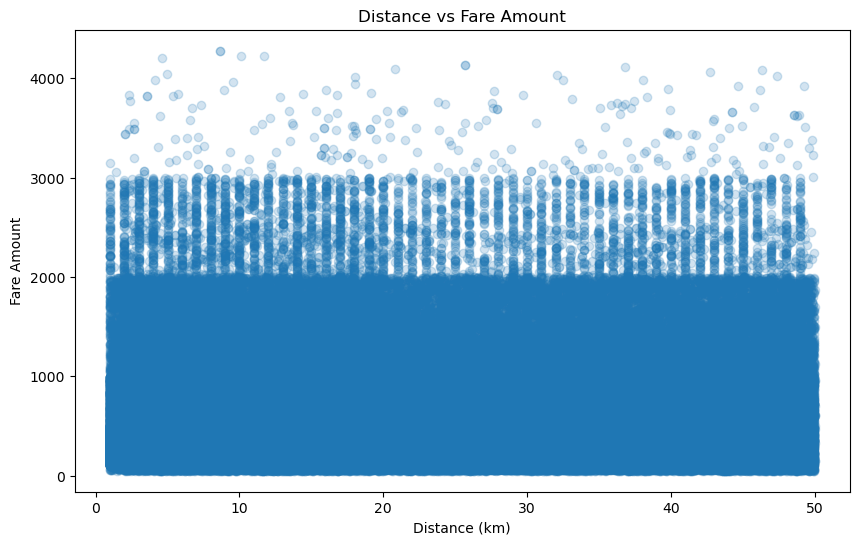

In [80]:
nonzero = df[df['distance_km'] > 0]

plt.figure(figsize=(10, 6))

plt.scatter(
    nonzero['distance_km'],
    nonzero['fare_amount'],
    alpha=0.2
)

plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount')
plt.title('Distance vs Fare Amount')
plt.show()

In [ ]:
df_model = df[df['distance_km'] > 0].copy()

In [81]:

df_raw = pd.read_csv(r"C:\Users\lenovo\.cache\kagglehub\datasets\parthrider04\synthetic-fare-dataset\versions\1\Synthetic_Fare_Dataset.csv")

nonzero = df_raw[df_raw['distance_km'] > 0]

report = nonzero.groupby('source_dataset').apply(
    lambda g: pd.Series({
        'n_rows': len(g),
        'distance_fare_corr': g['distance_km'].corr(g['fare_amount'])
    })
).sort_values('distance_fare_corr', ascending=False)

print(report)

                           n_rows  distance_fare_corr
source_dataset                                       
delhi_notification_2023     928.0        8.859688e-01
bengaluru_ola             33484.0        8.827997e-03
ncr_events               109329.0        4.605248e-03
bookings                  63967.0        1.885324e-03
aru_dto_2019                513.0       -3.597665e-16
indore_ola               100000.0       -5.598343e-05
rides_data                44964.0       -4.726441e-03


C:\Users\lenovo\AppData\Local\Temp\ipykernel_20500\190281091.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  report = nonzero.groupby('source_dataset').apply(


In [84]:
df

,vehicle_type,distance_km,fare_amount,payment_method,driver_rating,weekday,weather,phase_of_day
0,auto,28.50,868.06,wallet,4.4,Sunday,cloudy,morning
1,cab_ac,25.18,348.04,card,4.5,Wednesday,cloudy,night
2,bike,17.67,56.33,upi,3.6,Tuesday,cloudy,midnight
3,cab_suv,24.94,1971.38,upi,3.2,Monday,cloudy,morning
4,cab_ac,13.15,1130.15,card,3.1,Friday,cloudy,morning
...,...,...,...,...,...,...,...,...
392237,cab_ac,17.73,908.00,cash,4.2,Thursday,cloudy,evening
392238,bike,18.34,676.00,cash,3.9,Thursday,cloudy,evening
392239,cab_ac,9.28,780.00,cash,4.2,Wednesday,cloudy,night
392240,cab,3.32,1852.00,cash,4.2,Sunday,cloudy,night


In [173]:
si = SimpleImputer(strategy='median')

In [176]:
num_col = list(df.select_dtypes(include = "number").columns)
num_col

['distance_km', 'fare_amount', 'driver_rating']

In [178]:
df[num_col] = si.fit_transform(df[num_col])

In [180]:
OHE = OneHotEncoder(sparse_output=False)

In [193]:
df['phase_of_day'].value_counts()

phase_of_day
morning           102360
night              85999
afternoon          67402
evening            64229
midnight           41876
before_sunrise     22188
Name: count, dtype: int64

In [192]:
phase_of_day_encoded = OHE.fit_transform(df[["phase_of_day"]])
(pd.DataFrame(phase_of_day_encoded)).value_counts()

0    1    2    3    4    5  
0.0  0.0  0.0  0.0  1.0  0.0    102360
                    0.0  1.0     85999
1.0  0.0  0.0  0.0  0.0  0.0     67402
0.0  0.0  1.0  0.0  0.0  0.0     64229
          0.0  1.0  0.0  0.0     41876
     1.0  0.0  0.0  0.0  0.0     22188
Name: count, dtype: int64

In [196]:
df[["afternoon","before_sunrise","evening","midnight","morning","night"]] = phase_of_day_encoded

In [197]:
df

,vehicle_type,distance_km,fare_amount,payment_method,status,driver_rating,weekday,state,weather,phase_of_day,morning,night,afternoon,evening,midnight,before_sunrise
0,auto,28.50,868.06,wallet,success,4.4,Sunday,Karnataka,cloudy,morning,1.0,0.0,0.0,0.0,0.0,0.0
1,cab_ac,25.18,348.04,card,success,4.5,Wednesday,Karnataka,cloudy,night,0.0,1.0,0.0,0.0,0.0,0.0
2,bike,17.67,56.33,upi,success,3.6,Tuesday,Karnataka,cloudy,midnight,0.0,0.0,0.0,0.0,1.0,0.0
3,cab_suv,24.94,1971.38,upi,success,3.2,Monday,Karnataka,cloudy,morning,1.0,0.0,0.0,0.0,0.0,0.0
4,cab_ac,13.15,1130.15,card,success,3.1,Friday,Karnataka,cloudy,morning,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392237,cab_ac,17.73,908.00,cash,canceled by driver,4.2,Thursday,Madhya Pradesh,cloudy,evening,0.0,0.0,0.0,1.0,0.0,0.0
392238,bike,18.34,676.00,cash,success,3.9,Thursday,Madhya Pradesh,cloudy,evening,0.0,0.0,0.0,1.0,0.0,0.0
392239,cab_ac,9.28,780.00,cash,canceled by driver,4.2,Wednesday,Madhya Pradesh,cloudy,night,0.0,1.0,0.0,0.0,0.0,0.0
392240,cab,3.32,1852.00,cash,canceled by driver,4.2,Sunday,Madhya Pradesh,cloudy,night,0.0,1.0,0.0,0.0,0.0,0.0


In [199]:
te = TargetEncoder()

In [201]:
df.columns

Index(['vehicle_type', 'distance_km', 'fare_amount', 'payment_method',
       'status', 'driver_rating', 'weekday', 'state', 'weather',
       'phase_of_day', 'morning', 'night', 'afternoon', 'evening', 'midnight',
       'before_sunrise'],
      dtype='object')

In [205]:
vehicle_type_encoded = OHE.fit_transform(df[['vehicle_type']])

vehicle_type_encoded = pd.DataFrame(
    vehicle_type_encoded,
    columns=OHE.get_feature_names_out(['vehicle_type']),
    index=df.index
)

df = pd.concat([df, vehicle_type_encoded], axis=1)

In [206]:
payment_method_encoded = OHE.fit_transform(df[['payment_method']])

payment_method_encoded = pd.DataFrame(
    payment_method_encoded,
    columns=OHE.get_feature_names_out(['payment_method']),
    index=df.index
)

df = pd.concat([df, payment_method_encoded], axis=1)

In [207]:
weather_encoded = OHE.fit_transform(df[['weather']])

weather_encoded = pd.DataFrame(
    weather_encoded,
    columns=OHE.get_feature_names_out(['weather']),
    index=df.index
)

df = pd.concat([df, weather_encoded], axis=1)

In [208]:
phase_of_day_encoded = OHE.fit_transform(df[['phase_of_day']])

phase_of_day_encoded = pd.DataFrame(
    phase_of_day_encoded,
    columns=OHE.get_feature_names_out(['phase_of_day']),
    index=df.index
)

df = pd.concat([df, phase_of_day_encoded], axis=1)

In [211]:
day_encoded = OHE.fit_transform(df[['weekday']])

day_encoded = pd.DataFrame(
    day_encoded,
    columns=OHE.get_feature_names_out(['weekday']),
    index=df.index
)

df = pd.concat([df, day_encoded], axis=1)
df

,vehicle_type,distance_km,fare_amount,payment_method,status,driver_rating,weekday,state,weather,phase_of_day,...,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,weekday_Friday,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday
0,auto,28.50,868.06,wallet,success,4.4,Sunday,Karnataka,cloudy,morning,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,cab_ac,25.18,348.04,card,success,4.5,Wednesday,Karnataka,cloudy,night,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,bike,17.67,56.33,upi,success,3.6,Tuesday,Karnataka,cloudy,midnight,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,cab_suv,24.94,1971.38,upi,success,3.2,Monday,Karnataka,cloudy,morning,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,cab_ac,13.15,1130.15,card,success,3.1,Friday,Karnataka,cloudy,morning,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392237,cab_ac,17.73,908.00,cash,canceled by driver,4.2,Thursday,Madhya Pradesh,cloudy,evening,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
392238,bike,18.34,676.00,cash,success,3.9,Thursday,Madhya Pradesh,cloudy,evening,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
392239,cab_ac,9.28,780.00,cash,canceled by driver,4.2,Wednesday,Madhya Pradesh,cloudy,night,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
392240,cab,3.32,1852.00,cash,canceled by driver,4.2,Sunday,Madhya Pradesh,cloudy,night,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [212]:
categorical_cols = [
    'vehicle_type',
    'payment_method',
    'status',
    'weather',
    'phase_of_day',
    'weekday',
    'state',
]

OHE = OneHotEncoder(sparse_output=False)

encoded_data = OHE.fit_transform(df[categorical_cols])

encoded_df = pd.DataFrame(
    encoded_data,
    columns=OHE.get_feature_names_out(categorical_cols),
    index=df.index
)

df = pd.concat([df, encoded_df], axis=1)

In [228]:
df.columns

Index(['vehicle_type', 'distance_km', 'fare_amount', 'payment_method',
       'status', 'driver_rating', 'weekday', 'state', 'weather',
       'phase_of_day', 'morning', 'night', 'afternoon', 'evening', 'midnight',
       'before_sunrise', 'vehicle_type_auto', 'vehicle_type_bike',
       'vehicle_type_cab', 'vehicle_type_cab_ac', 'vehicle_type_cab_suv',
       'vehicle_type_premier_sedan', 'payment_method_card',
       'payment_method_cash', 'payment_method_upi', 'payment_method_wallet',
       'weather_cloudy', 'weather_raining', 'weather_sunny', 'weather_unknown',
       'phase_of_day_afternoon', 'phase_of_day_before_sunrise',
       'phase_of_day_evening', 'phase_of_day_midnight', 'phase_of_day_morning',
       'phase_of_day_night', 'weekday_Friday', 'weekday_Monday',
       'weekday_Saturday', 'weekday_Sunday', 'weekday_Thursday',
       'weekday_Tuesday', 'weekday_Wednesday', 'status_canceled by customer',
       'status_canceled by driver', 'status_completed',
       'status_driv

In [229]:
final_data=df[[ 'distance_km', 'fare_amount', 'driver_rating', 'morning', 'night', 'afternoon', 'evening', 'midnight',
       'before_sunrise', 'vehicle_type_auto', 'vehicle_type_bike',
       'vehicle_type_cab', 'vehicle_type_cab_ac', 'vehicle_type_cab_suv',
       'vehicle_type_premier_sedan', 'payment_method_card',
       'payment_method_cash', 'payment_method_upi', 'payment_method_wallet',
       'weather_cloudy', 'weather_raining', 'weather_sunny', 'weather_unknown',
       'phase_of_day_afternoon', 'phase_of_day_before_sunrise',
       'phase_of_day_evening', 'phase_of_day_midnight', 'phase_of_day_morning',
       'phase_of_day_night', 'weekday_Friday', 'weekday_Monday',
       'weekday_Saturday', 'weekday_Sunday', 'weekday_Thursday',
       'weekday_Tuesday', 'weekday_Wednesday', 'status_canceled by customer',
       'status_canceled by driver', 'status_completed',
       'status_driver not found', 'status_incomplete', 'status_success',
       'state_Delhi NCR', 'state_Karnataka', 'state_Madhya Pradesh']]

In [222]:
df.columns[df.columns.duplicated()]

Index(['vehicle_type_auto', 'vehicle_type_bike', 'vehicle_type_cab',
       'vehicle_type_cab_ac', 'vehicle_type_cab_suv',
       'vehicle_type_premier_sedan', 'vehicle_type_auto', 'vehicle_type_bike',
       'vehicle_type_cab', 'vehicle_type_cab_ac', 'vehicle_type_cab_suv',
       'vehicle_type_premier_sedan', 'weekday_Friday', 'weekday_Monday',
       'weekday_Saturday', 'weekday_Sunday', 'weekday_Thursday',
       'weekday_Tuesday', 'weekday_Wednesday', 'vehicle_type_auto',
       'vehicle_type_bike', 'vehicle_type_cab', 'vehicle_type_cab_ac',
       'vehicle_type_cab_suv', 'vehicle_type_premier_sedan',
       'payment_method_card', 'payment_method_cash', 'payment_method_upi',
       'payment_method_wallet', 'weather_cloudy', 'weather_raining',
       'weather_sunny', 'weather_unknown', 'phase_of_day_afternoon',
       'phase_of_day_before_sunrise', 'phase_of_day_evening',
       'phase_of_day_midnight', 'phase_of_day_morning', 'phase_of_day_night',
       'weekday_Friday', 'weekday

In [225]:
df.columns.duplicated().sum()

np.int64(46)

In [226]:
df = df.loc[:, ~df.columns.duplicated()]

In [227]:
df.columns.duplicated().sum()

np.int64(0)

In [230]:
X = final_data.drop(columns="fare_amount")
y = final_data["fare_amount"]

In [231]:
X_train,X_test,y_train,y_test =  train_test_split(X,y,test_size= 0.2, random_state=42)

In [232]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [233]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R²: 0.14674568162242974
MAE: 303.65240234163326
RMSE: 419.5694086514933


In [237]:
rf = RandomForestRegressor(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"ma

In [238]:
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest")
print("R²:", r2_rf)
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

Random Forest
R²: 0.05366334887283164
MAE: 314.0842043743697
RMSE: 441.86275743689544


In [239]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [240]:
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost")
print("R²:", r2_xgb)
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)

XGBoost
R²: 0.26153091529211336
MAE: 278.4924872625395
RMSE: 390.32891788096947


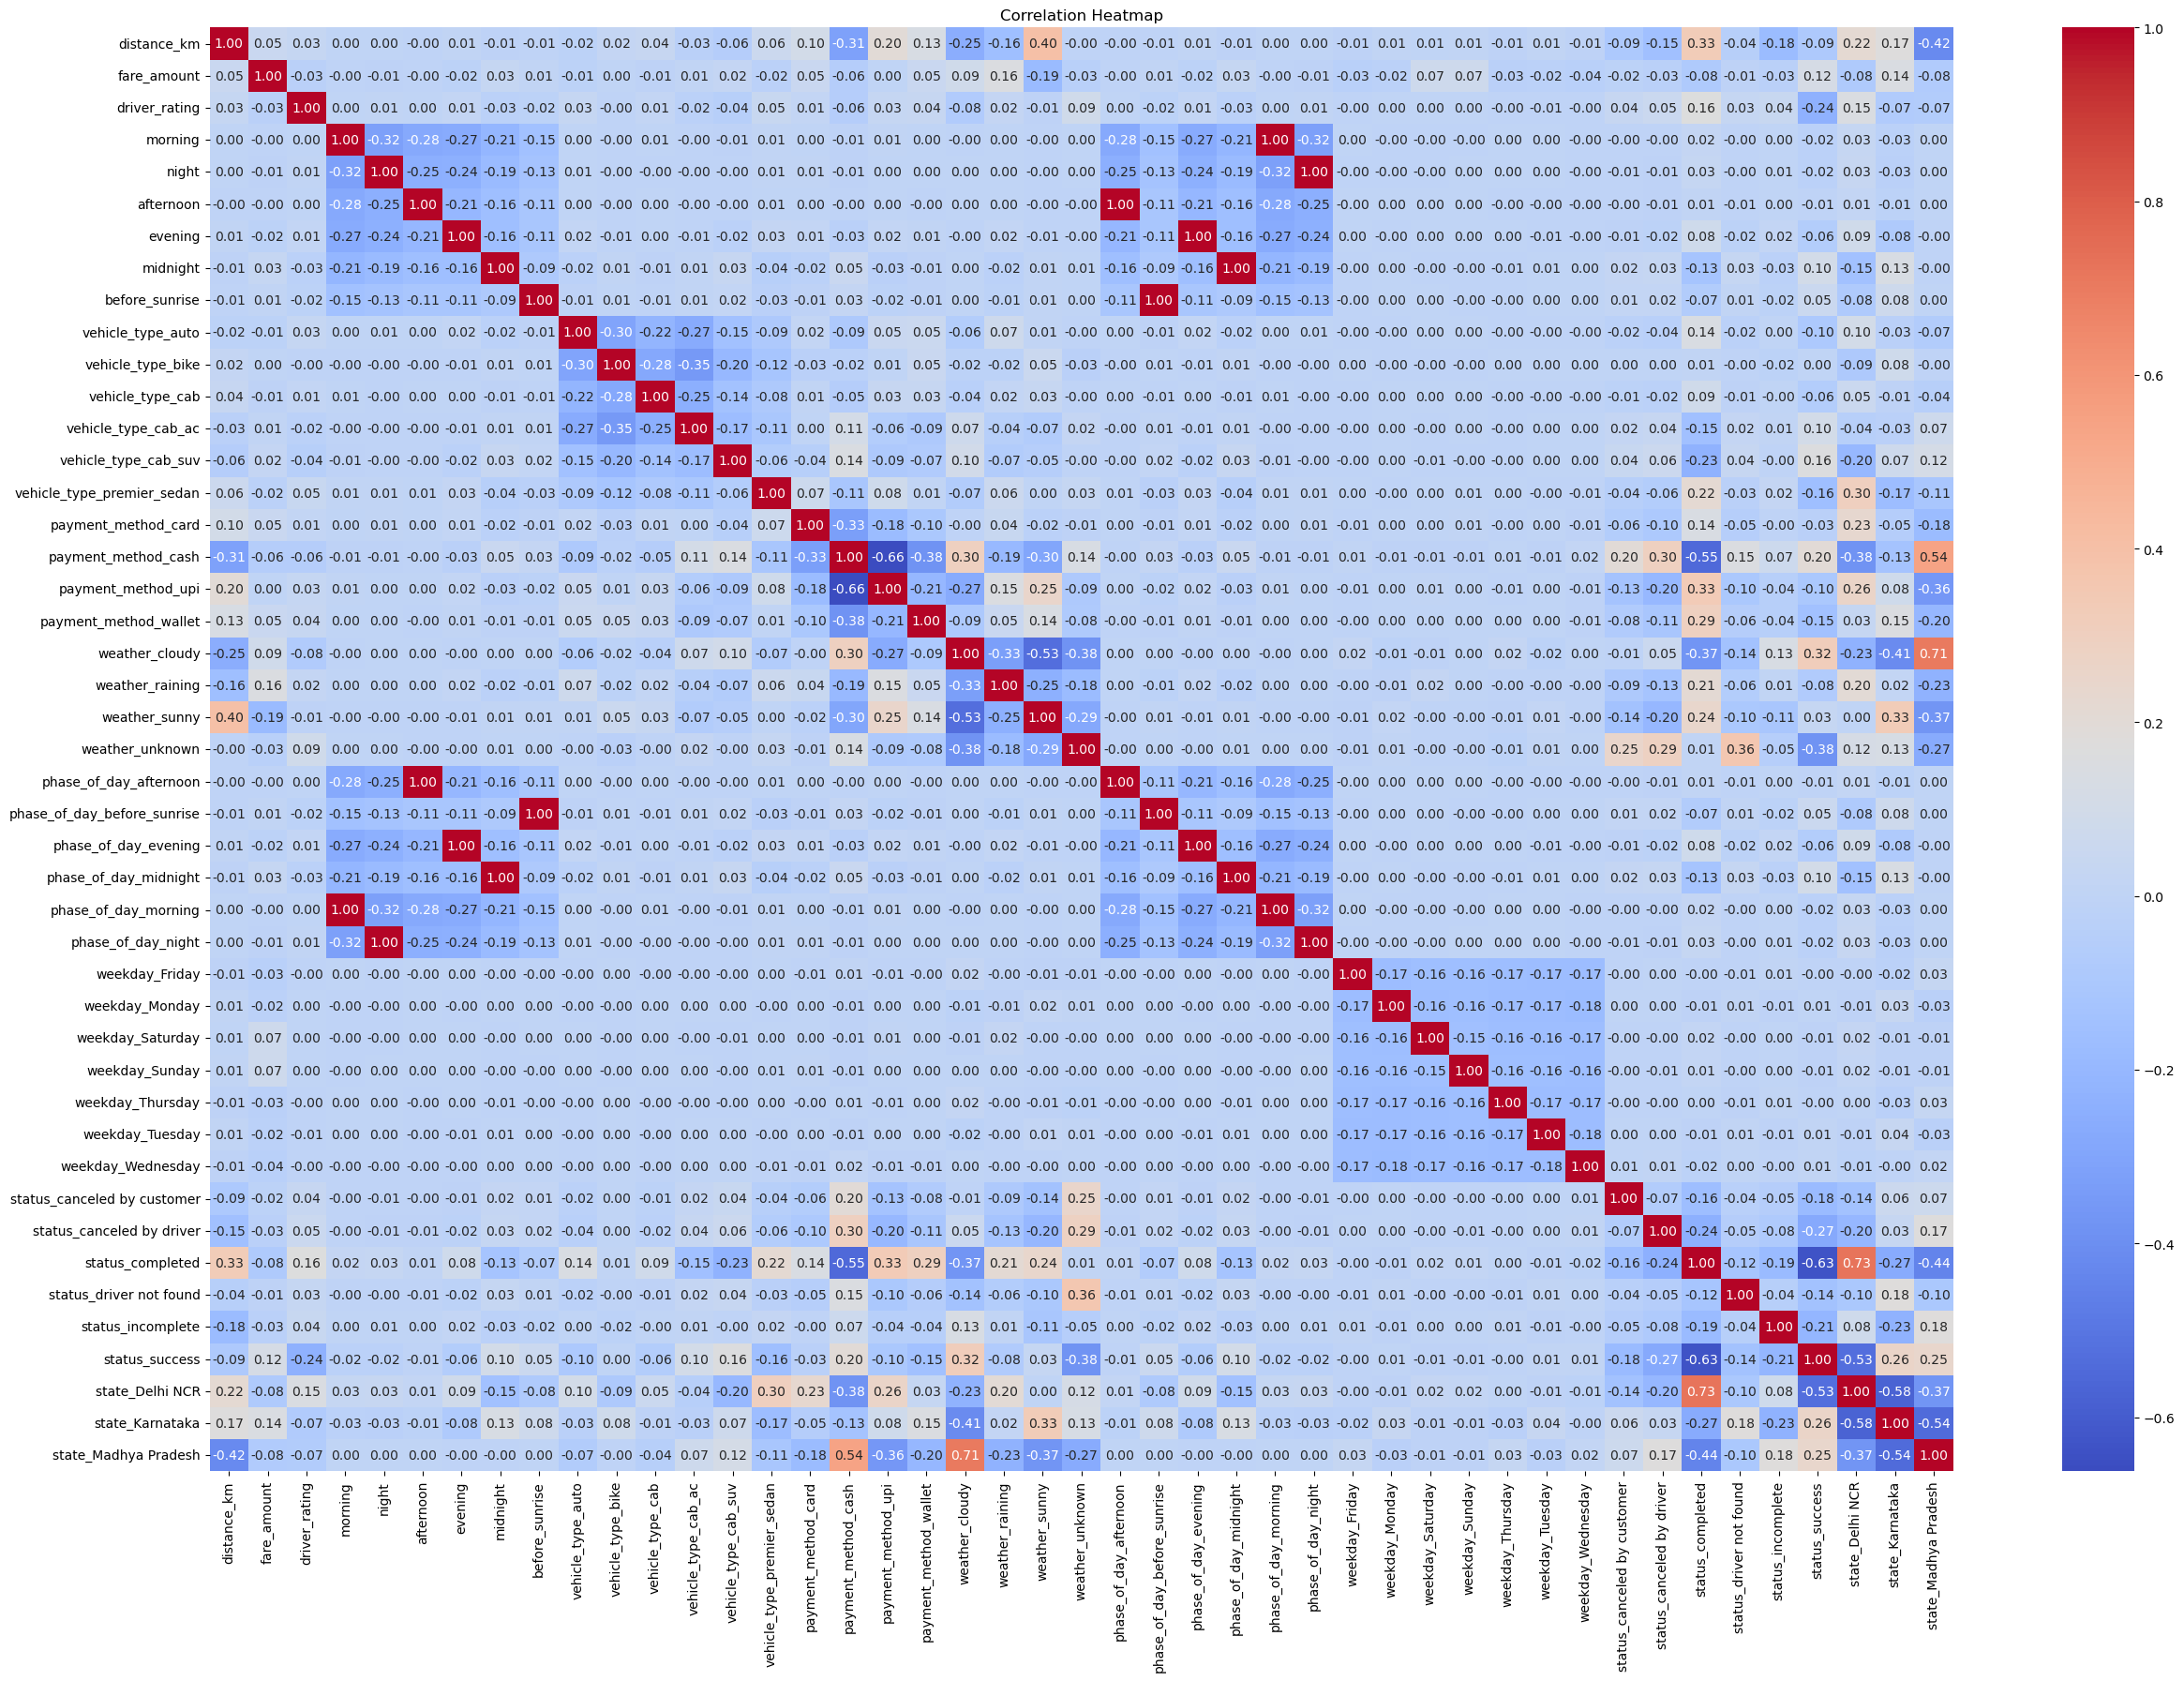

In [246]:
plt.figure(figsize=(30, 20))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

<Axes: xlabel='fare_amount', ylabel='Count'>

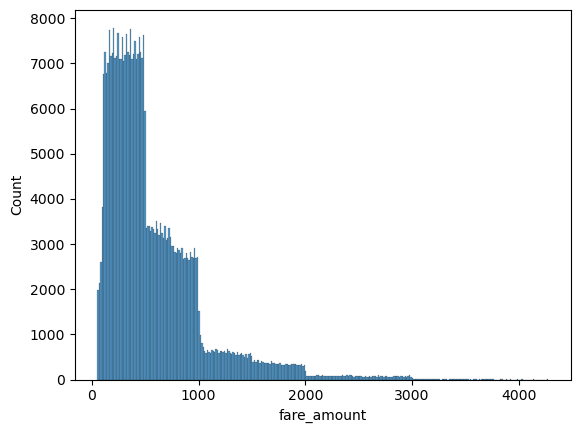

In [250]:
sns.histplot(y)

<Axes: xlabel='distance_km', ylabel='Count'>

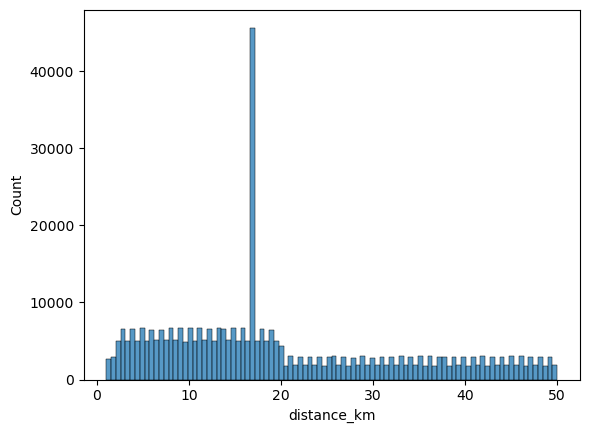

In [252]:
sns.histplot(df['distance_km'])

In [ ]:
df["sourcing_channel_encoded"] = te.fit_transform(data[["sourcing_channel"]], data["renewal"])